# 第 7 章 · 决策树与 KMeans 代码实验

[章节网页](../ch7.html)

## 运行内容

- 训练 sklearn 决策树
- 观察 KMeans 中心移动
- 绘制模型结果

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import subprocess
import sys
import warnings
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron, SGDRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, precision_recall_fscore_support
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备学生练习数据：特征进入模型，标签表示是否已经掌握。
tree_df = pd.DataFrame(
    [
        {"正确率": 0.92, "复盘次数": 3, "按时提交": 1, "掌握": 1},
        {"正确率": 0.85, "复盘次数": 2, "按时提交": 1, "掌握": 1},
        {"正确率": 0.78, "复盘次数": 2, "按时提交": 1, "掌握": 1},
        {"正确率": 0.73, "复盘次数": 3, "按时提交": 0, "掌握": 1},
        {"正确率": 0.66, "复盘次数": 1, "按时提交": 1, "掌握": 0},
        {"正确率": 0.60, "复盘次数": 2, "按时提交": 0, "掌握": 0},
        {"正确率": 0.58, "复盘次数": 0, "按时提交": 1, "掌握": 0},
        {"正确率": 0.52, "复盘次数": 1, "按时提交": 0, "掌握": 0},
        {"正确率": 0.48, "复盘次数": 0, "按时提交": 0, "掌握": 0},
        {"正确率": 0.88, "复盘次数": 1, "按时提交": 1, "掌握": 1},
    ]
)

feature_names = ["正确率", "复盘次数", "按时提交"]
class_names = ["未掌握", "已掌握"]
X_tree = tree_df[feature_names]
y_tree = tree_df["掌握"]
display(tree_df)

,正确率,复盘次数,按时提交,掌握
0,0.92,3,1,1
1,0.85,2,1,1
2,0.78,2,1,1
3,0.73,3,0,1
4,0.66,1,1,0
5,0.60,2,0,0
6,0.58,0,1,0
7,0.52,1,0,0
8,0.48,0,0,0
9,0.88,1,1,1


## 1. DecisionTreeClassifier

In [3]:
# 训练 sklearn 决策树，并输出每个样本的预测。
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=1, random_state=0)
tree.fit(X_tree, y_tree)

tree_pred = tree.predict(X_tree)
tree_result = tree_df.copy()
tree_result["预测"] = tree_pred
tree_result["预测含义"] = np.where(tree_pred == 1, "已掌握", "未掌握")
tree_result["预测正确"] = tree_result["预测"].eq(tree_result["掌握"])
display(tree_result)
print("训练集准确率:", round(accuracy_score(y_tree, tree_pred), 3))

,正确率,复盘次数,按时提交,掌握,预测,预测含义,预测正确
0,0.92,3,1,1,1,已掌握,True
1,0.85,2,1,1,1,已掌握,True
2,0.78,2,1,1,1,已掌握,True
3,0.73,3,0,1,1,已掌握,True
4,0.66,1,1,0,0,未掌握,True
5,0.60,2,0,0,0,未掌握,True
6,0.58,0,1,0,0,未掌握,True
7,0.52,1,0,0,0,未掌握,True
8,0.48,0,0,0,0,未掌握,True
9,0.88,1,1,1,1,已掌握,True


训练集准确率: 1.0


In [4]:
# 查看树的分裂规则和特征贡献。
importance_df = pd.DataFrame(
    {"特征": feature_names, "重要度": tree.feature_importances_}
).sort_values("重要度", ascending=False)

print(export_text(tree, feature_names=feature_names))
display(importance_df)

|--- 正确率 <= 0.70
|   |--- class: 0
|--- 正确率 >  0.70
|   |--- class: 1



,特征,重要度
0,正确率,1.0
1,复盘次数,0.0
2,按时提交,0.0


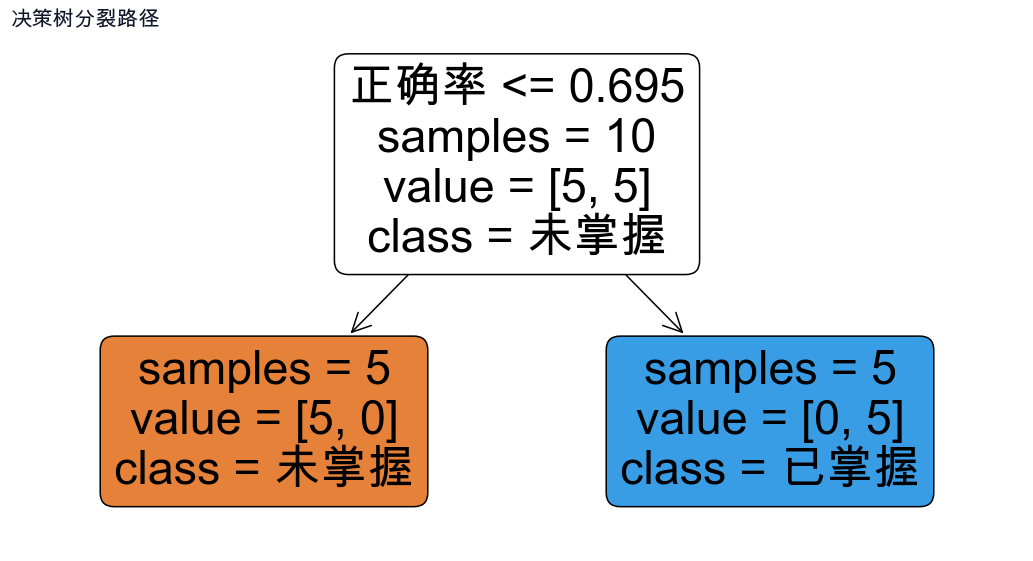

In [5]:
# 绘制 sklearn 训练出的树结构。
fig, ax = plt.subplots(figsize=(9.5, 5.2))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=False,
    ax=ax,
)
ax.set_title("决策树分裂路径", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()

## 2. KMeans

In [6]:
# 准备二维学习行为点：横轴是测验分，纵轴是项目分。
kmeans_points = pd.DataFrame(
    {
        "学生": ["A", "B", "C", "D", "E", "F", "G", "H"],
        "测验分": [92, 88, 85, 79, 62, 58, 54, 49],
        "项目分": [86, 82, 90, 76, 60, 55, 49, 45],
    }
)
X_cluster = kmeans_points[["测验分", "项目分"]].to_numpy()
display(kmeans_points)

,学生,测验分,项目分
0,A,92,86
1,B,88,82
2,C,85,90
3,D,79,76
4,E,62,60
5,F,58,55
6,G,54,49
7,H,49,45


In [7]:
# 用 sklearn KMeans 连续跑几个单步迭代，观察中心如何移动。
centers = np.array([[58.0, 55.0], [88.0, 84.0]])
center_rows = []
label_history = []

for iteration in range(1, 5):
    km_step = KMeans(n_clusters=2, init=centers, n_init=1, max_iter=1, random_state=0)
    labels = km_step.fit_predict(X_cluster)
    centers = km_step.cluster_centers_
    label_history.append(labels)
    for cluster_id, (cx, cy) in enumerate(centers):
        center_rows.append({
            "迭代": iteration,
            "簇": cluster_id,
            "中心_测验分": round(cx, 2),
            "中心_项目分": round(cy, 2),
            "簇内样本数": int((labels == cluster_id).sum()),
        })

kmeans = KMeans(n_clusters=2, init=centers, n_init=1, max_iter=50, random_state=0)
final_labels = kmeans.fit_predict(X_cluster)
kmeans_points["簇"] = final_labels

centers_df = pd.DataFrame(center_rows)
display(centers_df)
display(kmeans_points)

,迭代,簇,中心_测验分,中心_项目分,簇内样本数
0,1,0,55.75,52.25,4
1,1,1,86.00,83.50,4
2,2,0,55.75,52.25,4
3,2,1,86.00,83.50,4
4,3,0,55.75,52.25,4
5,3,1,86.00,83.50,4
6,4,0,55.75,52.25,4
7,4,1,86.00,83.50,4


,学生,测验分,项目分,簇
0,A,92,86,1
1,B,88,82,1
2,C,85,90,1
3,D,79,76,1
4,E,62,60,0
5,F,58,55,0
6,G,54,49,0
7,H,49,45,0


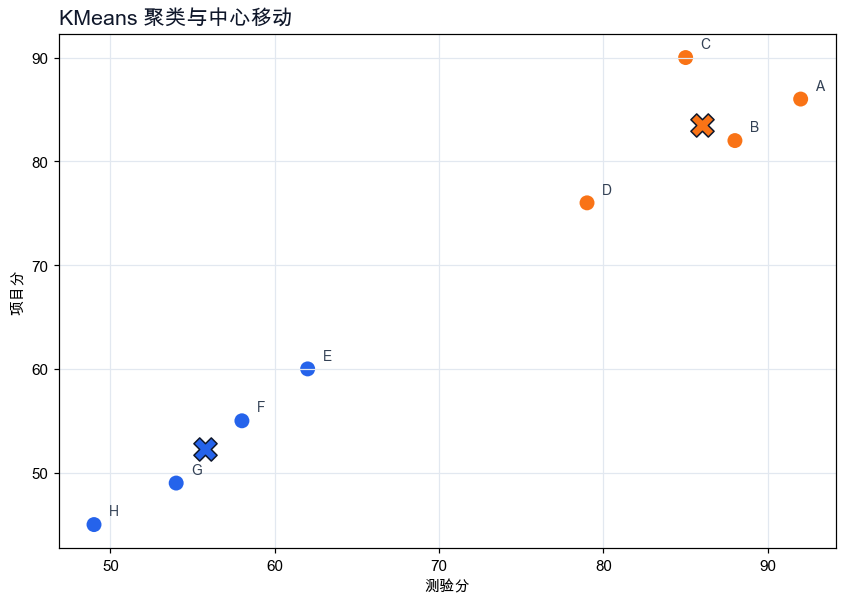

In [8]:
# 绘制最终聚类结果和中心移动轨迹。
fig, ax = plt.subplots(figsize=(7.8, 5.6))
palette = np.array(["#2563eb", "#f97316"])
ax.scatter(
    kmeans_points["测验分"],
    kmeans_points["项目分"],
    c=palette[final_labels],
    s=130,
    edgecolors="white",
    linewidth=1.6,
)
for _, row in kmeans_points.iterrows():
    ax.text(row["测验分"] + 0.9, row["项目分"] + 0.9, row["学生"], fontsize=9, color="#334155")

for cluster_id in sorted(centers_df["簇"].unique()):
    path = centers_df[centers_df["簇"] == cluster_id]
    ax.plot(path["中心_测验分"], path["中心_项目分"], "--", color=palette[cluster_id], linewidth=1.8)
    ax.scatter(
        [kmeans.cluster_centers_[cluster_id, 0]],
        [kmeans.cluster_centers_[cluster_id, 1]],
        marker="X",
        s=230,
        color=palette[cluster_id],
        edgecolors="#0f172a",
        linewidth=1.0,
    )

ax.set_title("KMeans 聚类与中心移动", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("测验分")
ax.set_ylabel("项目分")
ax.grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()